# Acessorio(a) - Análises gerais - Histograma queries

Esse caderno é para plotar o histograma do tamanho das queries. 

É numerado como Acessorio porque não é um caderno essencial, são apenas testes.

In [1]:
import pandas as pd

PASTA_DADOS = './dados/'
# A pasta dos JURIS aqui não é a pasta original, e sim o resultado do caderno 1 (os documentos já estão filtrados)
PASTA_JURIS_TCU = f'{PASTA_DADOS}outputs/1_tratamento_juris_tcu/'

# Carrega os arquivos 
def carrega_juris_tcu():
    doc1 = pd.read_csv(f'{PASTA_JURIS_TCU}doc_tratado_parte_1.csv', sep='|')
    doc2 = pd.read_csv(f'{PASTA_JURIS_TCU}doc_tratado_parte_2.csv', sep='|')
    doc3 = pd.read_csv(f'{PASTA_JURIS_TCU}doc_tratado_parte_3.csv', sep='|')
    doc4 = pd.read_csv(f'{PASTA_JURIS_TCU}doc_tratado_parte_4.csv', sep='|')
    doc = pd.concat([doc1, doc2, doc3, doc4], ignore_index=True)
    query = pd.read_csv(f'{PASTA_JURIS_TCU}query_tratado.csv', sep='|')
    qrel = pd.read_csv(f'{PASTA_JURIS_TCU}qrel_tratado.csv', sep='|')

    return doc, query, qrel

docs, queries, qrels = carrega_juris_tcu()

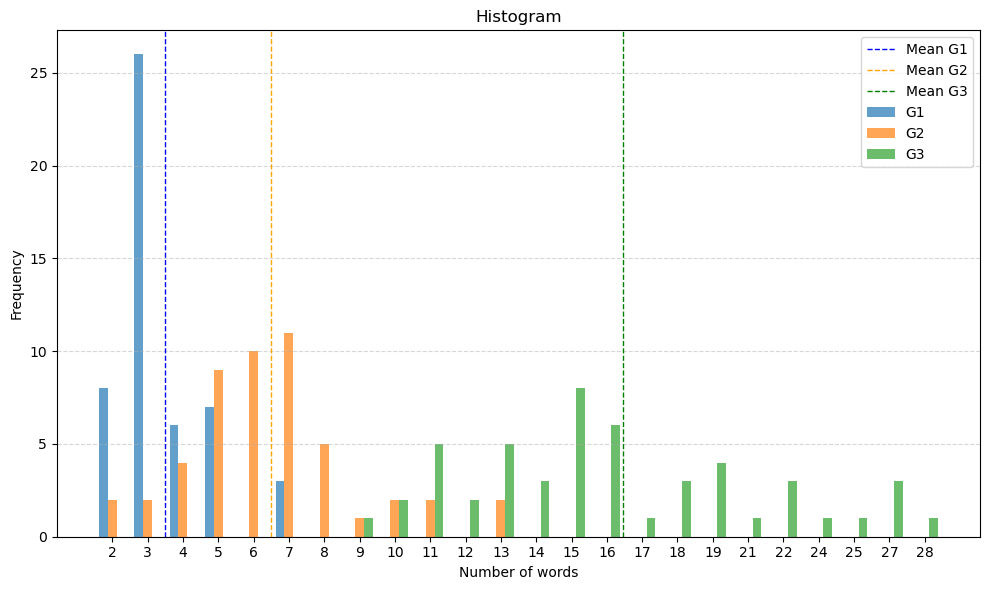

In [22]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_histogram(array1, array2, array3, labels):
    # Contar a quantidade de palavras em cada string
    word_counts1 = [len(s.split()) for s in array1]
    word_counts2 = [len(s.split()) for s in array2]
    word_counts3 = [len(s.split()) for s in array3]
    
    # Calcular as médias
    mean1 = np.mean(word_counts1)
    mean2 = np.mean(word_counts2)
    mean3 = np.mean(word_counts3)
    
    # Contar a frequência de cada quantidade de palavras
    counter1 = Counter(word_counts1)
    counter2 = Counter(word_counts2)
    counter3 = Counter(word_counts3)
    
    # Obter todas as quantidades únicas de palavras
    all_keys = sorted(set(counter1.keys()) | set(counter2.keys()) | set(counter3.keys()))
    key_index = {key: i for i, key in enumerate(all_keys)}  # Mapear valores reais para os índices do eixo X
    
    # Criar listas de frequências
    freq1 = [counter1[key] for key in all_keys]
    freq2 = [counter2[key] for key in all_keys]
    freq3 = [counter3[key] for key in all_keys]
    
    x = np.arange(len(all_keys))  # Posições no eixo X
    width = 0.25  # Largura das barras
    
    # Criar o gráfico de barras
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width, freq1, width, label=labels[0], alpha=0.7)
    ax.bar(x, freq2, width, label=labels[1], alpha=0.7)
    ax.bar(x + width, freq3, width, label=labels[2], alpha=0.7)

    # Adicionar linhas de grade horizontais tracejadas
    ax.yaxis.grid(True, linestyle='dashed', alpha=0.5)
    
    # Plotar as médias corretamente sem arredondamento
    ax.axvline(np.interp(mean1, all_keys, x), color='blue', linestyle='dashed', linewidth=1, label=f'Mean {labels[0]}')
    ax.axvline(np.interp(mean2, all_keys, x), color='orange', linestyle='dashed', linewidth=1, label=f'Mean {labels[1]}')
    ax.axvline(np.interp(mean3, all_keys, x), color='green', linestyle='dashed', linewidth=1, label=f'Mean {labels[2]}')
    
    # Ajustar rótulos e legenda
    ax.set_xlabel("Number of words")
    ax.set_ylabel("Frequency")
    ax.set_title("Histogram")
    ax.set_xticks(x)
    ax.set_xticklabels(all_keys)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# Exemplo de uso
queries_list = queries.TEXT.tolist()
g1 = queries_list[0:50]
g2 = queries_list[50:100]
g3 = queries_list[100:150]
labels = ["G1", "G2", "G3"]
plot_histogram(g1, g2, g3, labels)